# R09 structure markers - H62 structural twins, H64 betweenness bottlenecks, H65 assortativity, H66 k-core fingerprint

**Author**: Knowledge Graph Foundry autonomous build (kj) <br>
**Date**: 2026-07-07 <br>
**Pipeline stage**: R09 graph topology round, structural-signal family <br>
**Graph**: rebuilt CPAP graph (neo4j2, READ-ONLY), 28-probe gold set <br>

Four structural-signal hypotheses on the projected entity graph (2531 connected nodes,
median degree 1, giant component 2434). Every graph mutation (corruption, merge-undo) runs on
an in-memory networkx copy - the Neo4j instance is never written.

- **H62** - does neighbor-Jaccard rank duplicates above embedding cosine? bar Jaccard MAP > embedding MAP and combined dominates
- **H64** - do seed-to-gold paths concentrate through few high-betweenness nodes, and does corrupting a bottleneck hurt >=3x a random node?
- **H65** - degree assortativity r stays disassortative (< -0.05) and rises monotonically under merge-undo injection, detectable at >=10%
- **H66** - does gold evidence concentrate in the middle k-core shells (>=70% in shells 2..k_max-1)?

Sparsity risk (per H87/H88): median degree 1, few triangles - structural signals are expected to be starved. Reported honestly.

## Outputs
- `reports/structure-markers-r09-<stamp>.json` - MAP table, path concentration, corruption ratio, assortativity curve, shell profile, verdicts

In [1]:
# Imports
# stdlib
import datetime, json, os, re, random
from collections import Counter, deque

# third party
import numpy as np
import networkx as nx
import yaml
import matplotlib.pyplot as plt
from pathlib import Path
from rich import print as rprint
from rich.progress import Progress

os.environ["NEO4J_URI"] = "bolt://user-konrad.jelen-kgf-neo4j2:7687"
os.environ["NEO4J_USER"] = "neo4j"
os.environ["NEO4J_PASSWORD"] = "kgfoundry"
random.seed(42); np.random.seed(42)

# project
from knowledge_graph_foundry import Foundry, load_settings
from knowledge_graph_foundry.extraction import generate_embeddings
from knowledge_graph_foundry.graph.graphrag import vector_query
from knowledge_graph_foundry.graph.propositions import proposition_query
from knowledge_graph_foundry.models import Entity

2026-07-07 11:09:08.631 | INFO     | knowledge_graph_foundry.config:<module>:40 - PROJ_ROOT path is: /home/lab/workspace/learning/projects/knowledge-graph-foundry


In [2]:
# Configuration
PROBES_PATH = Path("../tests/probes/cpap-probe-set.yml")
settings = load_settings(Path("../config.yml"))
TOP_K = settings.graphrag.top_k
PROP_TOP_K = settings.graphrag.proposition_top_k
VEC_INDEX = settings.graphrag.vector_index_name
PROP_INDEX = settings.graphrag.proposition_index_name

# pre-registered bars
BAR_H64_PATHSHARE = 0.50   # top-1% betweenness on >=50% of seed-to-gold paths
BAR_H64_DAMAGE = 3.0       # bottleneck corruption >= 3x random
BAR_H65_BAND = -0.05       # r < -0.05 disassortative band
BAR_H65_INJ = 0.10         # detectable rise at >=10% injection
BAR_H66_SHELLS = 0.70      # >=70% gold in shells 2..k_max-1

probes = yaml.safe_load(PROBES_PATH.read_text())
gold_probes = [p for p in probes if p.get("gold_evidence")]
n_golds = sum(len(p["gold_evidence"]) for p in gold_probes)

rprint(f"""[bold cyan]Configuration[/bold cyan]
[dim]{"\u2500" * 40}[/dim]
[bold]Graph[/bold] neo4j2 (read-only)  probes [yellow]{len(gold_probes)}[/yellow]  golds [yellow]{n_golds}[/yellow]
[bold]Bars[/bold] H64 path-share >= [yellow]{BAR_H64_PATHSHARE}[/yellow] damage >= [yellow]{BAR_H64_DAMAGE}[/yellow]x  H65 band < [yellow]{BAR_H65_BAND}[/yellow] inj@[yellow]{BAR_H65_INJ}[/yellow]  H66 shells >= [yellow]{BAR_H66_SHELLS}[/yellow]
""")

Configuration
────────────────────────────────────────
Graph neo4j2 (read-only)  probes 24  golds 33
Bars H64 path-share >= 0.5 damage >= 3.0x  H65 band < -0.05 inj@0.1  H66 shells >= 0.7

## Graph snapshot, carriers, seeds, betweenness

Load entities (with 1024-d embeddings), valid non-SIMILAR_TO edges, attached propositions.
Build the networkx entity graph, gold carriers via the H67 `present()` matcher, per-probe
production seeds (vector top-8 + proposition-derived), and exact GDS node betweenness.

In [3]:
# H67 present() matcher - verbatim
def _norm(s):
    return re.sub(r"\s+", " ", s.casefold())
def value_tokens(text):
    return re.findall(r"[\w.\-/]*\d[\w.\-/]*", text)
_UNIT = r"(?<=\d)\s*(mm|cm|dba|db\(a\)|db|kg|g|oz|ml|l|w|hz|mins|min|m)\b"
def present(gold, ctx_norm):
    ng = _norm(gold)
    if ng in ctx_norm:
        return True
    squashed = re.sub(r"[\s,()]", "", ctx_norm)
    skeleton = re.sub(r"[\s,()]", "", re.sub(_UNIT, "", ng))
    if any(ch.isdigit() for ch in skeleton) and len(skeleton) >= 5 and skeleton in squashed:
        return True
    tokens = value_tokens(gold)
    if tokens:
        hit = sum(1 for t in tokens if _norm(t) in ctx_norm or re.sub(r"[\s,()]", "", _norm(t)) in squashed)
        return hit >= max(1, len(tokens) // 2 + (len(tokens) % 2))
    words = set(re.findall(r"[a-z][a-z0-9\-]{2,}", ng))
    ctx_words = set(re.findall(r"[a-z][a-z0-9\-]{2,}", ctx_norm))
    return bool(words) and len(words & ctx_words) / len(words) >= 0.6

In [4]:
# load graph + embeddings + betweenness
with Foundry(settings) as f:
    with f.driver.session() as s:
        ents = s.run(
            "MATCH (e:Entity) RETURN e.id AS id, e.name AS name, e.description AS description, "
            "properties(e) AS props, e.embedding AS emb"
        ).data()
        edges = s.run(
            "MATCH (a:Entity)-[r]-(b:Entity) "
            "WHERE r.valid_to IS NULL AND type(r) <> 'SIMILAR_TO' AND a.id < b.id "
            "RETURN DISTINCT a.id AS a, b.id AS b, type(r) AS rel"
        ).data()
        prop_rows = s.run(
            "MATCH (p:Proposition)-[:ABOUT]->(e:Entity) RETURN e.id AS eid, p.text AS text"
        ).data()
        try:
            s.run("CALL gds.graph.drop('r09btw', false)")
        except Exception:
            pass
        s.run("MATCH (a:Entity)-[r]-(b:Entity) WHERE type(r) <> 'SIMILAR_TO' "
              "WITH gds.graph.project('r09btw', a, b, {}, {undirectedRelationshipTypes:['*']}) AS g RETURN g.nodeCount AS n")
        btw_rows = s.run(
            "CALL gds.betweenness.stream('r09btw') YIELD nodeId, score "
            "WITH gds.util.asNode(nodeId) AS n, score RETURN n.id AS eid, score"
        ).data()
        s.run("CALL gds.graph.drop('r09btw', false)")

names = {r["id"]: r["name"] for r in ents}
emb = {r["id"]: np.array(r["emb"], dtype=np.float32) for r in ents if r["emb"]}
betweenness = {r["eid"]: r["score"] for r in btw_rows}
by_ent_props = {}
for r in prop_rows:
    by_ent_props.setdefault(r["eid"], []).append(r["text"])

# networkx simple graph
G = nx.Graph()
G.add_nodes_from(r["id"] for r in ents)
for e_ in edges:
    G.add_edge(e_["a"], e_["b"], rel=e_["rel"])
adj = {n: set(G.neighbors(n)) for n in G.nodes}

# carrier surfaces (full: name + desc + spec + props + rel lines)
rel_lines = {}
for e_ in edges:
    rel_lines.setdefault(e_["a"], []).append(f"{e_['rel']} {names.get(e_['b'],'')}")
    rel_lines.setdefault(e_["b"], []).append(f"{e_['rel']} {names.get(e_['a'],'')}")
surface = {}
for r in ents:
    spec = {k.removeprefix("prop_"): v for k, v in r["props"].items() if k.startswith("prop_")}
    surface[r["id"]] = _norm(" ".join([
        r["name"] or "", r["description"] or "", json.dumps(spec, default=str),
        " ".join(by_ent_props.get(r["id"], [])), " ".join(rel_lines.get(r["id"], []))]))

carriers = {}
for p in gold_probes:
    for g in p["gold_evidence"]:
        carriers[(p["id"], g)] = [eid for eid, t in surface.items() if present(g, t)]

rprint(f"entities [yellow]{len(ents)}[/yellow]  nx nodes [yellow]{G.number_of_nodes()}[/yellow] "
       f"edges [yellow]{G.number_of_edges()}[/yellow]  embeddings [yellow]{len(emb)}[/yellow]  "
       f"betweenness scored [yellow]{len(betweenness)}[/yellow]")

Received notification from DBMS server: <GqlStatusObject gql_status='01N52', status_description='warn: property key does not exist. The property `valid_to` does not exist. Verify that the spelling is correct.', position=<SummaryInputPosition line=1, column=41, offset=40>, raw_classification='UNRECOGNIZED', classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'UNRECOGNIZED', '_severity': 'WARNING', '_position': {'offset': 40, 'line': 1, 'column': 41}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "MATCH (a:Entity)-[r]-(b:Entity) WHERE r.valid_to IS NULL AND type(r) <> 'SIMILAR_TO' AND a.id < b.id RETURN DISTINCT a.id AS a, b.id AS b, type(r) AS rel"


Received notification from DBMS server: <GqlStatusObject gql_status='01N03', status_description='warn: procedure field deprecated. The field `schema` of procedure gds.graph.drop() is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "CALL gds.graph.drop('r09btw', false)"


Received notification from DBMS server: <GqlStatusObject gql_status='01N03', status_description='warn: procedure field deprecated. The field `schema` of procedure gds.graph.drop() is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "CALL gds.graph.drop('r09btw', false)"


entities 2798  nx nodes 2798 edges 3738  embeddings 2798  betweenness scored 2531

In [5]:
# per-probe production seeds (vec-8 + prop-derived)
seeds_by_probe = {}
with Foundry(settings) as f, Progress() as progress:
    task = progress.add_task("seeds", total=len(gold_probes))
    for p in gold_probes:
        q_ = p["question"]
        probe_e = Entity.create(q_[:80], types=["Query"], description=q_)
        e = generate_embeddings([probe_e], settings.embeddings)[0].embedding
        vec = [x["id"] for x in vector_query(f.driver, e, VEC_INDEX, top_k=TOP_K)]
        prop_hits = proposition_query(f.driver, e, PROP_INDEX, top_k=PROP_TOP_K)
        prop_ids = [eid for h in prop_hits for eid in h["entity_ids"] if eid not in vec]
        seeds_by_probe[p["id"]] = [i for i in vec + prop_ids if i in G]
        progress.advance(task)
rprint(f"[green]seeds computed[/green] for {len(seeds_by_probe)} probes")

/home/lab/workspace/learning/projects/knowledge-graph-foundry/.venv/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

2026-07-07 11:09:20.088 | INFO     | knowledge_graph_foundry.extraction.embeddings:_embed_bedrock:91 - Embeddings: 
1/1

2026-07-07 11:09:20.090 | INFO     | knowledge_graph_foundry.extraction.embeddings:generate_embeddings:199 - 
Generated embeddings for 1/1 entities via bedrock (0 cache hits)

2026-07-07 11:09:20.382 | INFO     | knowledge_graph_foundry.extraction.embeddings:_embed_bedrock:91 - Embeddings: 
1/1

2026-07-07 11:09:20.384 | INFO     | knowledge_graph_foundry.extraction.embeddings:generate_embeddings:199 - 
Generated embeddings for 1/1 entities via bedrock (0 cache hits)

...

2026-07-07 11:09:32.247 | INFO     | knowledge_graph_foundry.extraction.embeddings:_embed_bedrock:91 - Embeddings: 
1/1

2026-07-07 11:09:32.249 | INFO     | knowledge_graph_foundry.extraction.embeddings:generate_embeddings:199 - 
Generated embeddings for 1/1 entities via bedrock (0 cache hits)

2026-07-07 11:09:32.837 | INFO     | knowledge_graph_foundry.extraction.embeddings:_embed_bedrock:91 - Embeddings: 
1/1

2026-07-07 11:09:32.890 | INFO     | knowledge_graph_foundry.extraction.embeddings:generate_embeddings:199 - 
Generated embeddings for 1/1 entities via bedrock (0 cache hits)

seeds computed for 24 probes

## H62 - structural twins: neighbor-Jaccard vs embedding cosine

The 66 labeled duplicate pairs (R11 identity forensics) are the positives. For each entity that
participates in a labeled pair, rank all other entities by neighbor-set Jaccard, by embedding
cosine, and by a min-max-normalized combination; the relevant items are its labeled partners.
MAP is the mean average precision over those query entities. The false-positive head of the
Jaccard ranking is inspected for same-family siblings (shared model token).

In [6]:
# H62 MAP comparison
forensics = json.load(open("../reports/identity-forensics-r11-final-20260706-205147.json"))
name2ids = {}
for r in ents:
    name2ids.setdefault((r["name"] or "").casefold(), []).append(r["id"])
def first_id(name):
    v = name2ids.get((name or "").casefold())
    return v[0] if v else None

positives = {}
for pr in forensics["pairs"]:
    ia, ib = first_id(pr["a"]), first_id(pr["b"])
    if ia and ib and ia != ib:
        positives.setdefault(ia, set()).add(ib)
        positives.setdefault(ib, set()).add(ia)

query_ids = [q for q in positives if q in emb]
all_ids = [r["id"] for r in ents if r["id"] in emb]
EM = np.stack([emb[i] for i in all_ids])
EM = EM / (np.linalg.norm(EM, axis=1, keepdims=True) + 1e-9)
idx = {i: k for k, i in enumerate(all_ids)}

def jaccard(q, c):
    a, b = adj.get(q, set()), adj.get(c, set())
    if not a and not b:
        return 0.0
    u = len(a | b)
    return len(a & b) / u if u else 0.0

def average_precision(ranked, relevant):
    hits, ap = 0, 0.0
    for rank, cid in enumerate(ranked, 1):
        if cid in relevant:
            hits += 1
            ap += hits / rank
    return ap / len(relevant) if relevant else 0.0

def minmax(x):
    lo, hi = x.min(), x.max()
    return (x - lo) / (hi - lo) if hi > lo else np.zeros_like(x)

ap_j, ap_e, ap_c = [], [], []
jaccard_fp_head = []  # (query, candidate, jac) top false positives
for q in query_ids:
    rel = positives[q]
    cands = [i for i in all_ids if i != q]
    cvec = EM[[idx[c] for c in cands]]
    cos = cvec @ EM[idx[q]]
    jac = np.array([jaccard(q, c) for c in cands])
    comb = minmax(cos) + minmax(jac)
    order_j = [cands[k] for k in np.argsort(-jac, kind="stable")]
    order_e = [cands[k] for k in np.argsort(-cos, kind="stable")]
    order_c = [cands[k] for k in np.argsort(-comb, kind="stable")]
    ap_j.append(average_precision(order_j, rel))
    ap_e.append(average_precision(order_e, rel))
    ap_c.append(average_precision(order_c, rel))
    for cid in order_j[:3]:
        if cid not in rel and jaccard(q, cid) > 0:
            jaccard_fp_head.append((names.get(q), names.get(cid), round(jaccard(q, cid), 3)))

map_j, map_e, map_c = float(np.mean(ap_j)), float(np.mean(ap_e)), float(np.mean(ap_c))

# sibling share of Jaccard false-positive head (shared alnum model token >=3 chars)
def tokens(nm):
    return set(re.findall(r"[a-z0-9]{3,}", (nm or "").casefold()))
sib = sum(1 for qn, cn, _ in jaccard_fp_head if tokens(qn) & tokens(cn))
sib_share = sib / len(jaccard_fp_head) if jaccard_fp_head else 0.0

h62_verdict = ("CONFIRMED" if map_j > map_e and map_c > max(map_j, map_e) else "REFUTED")
rprint(f"""[bold cyan]H62 structural twins[/bold cyan]
[dim]{"\u2500" * 40}[/dim]
  query entities: [yellow]{len(query_ids)}[/yellow]  positive pairs [yellow]{sum(len(v) for v in positives.values())//2}[/yellow]
  MAP jaccard: [yellow]{map_j:.3f}[/yellow]   MAP embedding: [yellow]{map_e:.3f}[/yellow]   MAP combined: [yellow]{map_c:.3f}[/yellow]
  Jaccard FP-head sibling share: [yellow]{sib_share:.2f}[/yellow] ({sib}/{len(jaccard_fp_head)})
  Verdict: [{'green' if h62_verdict == 'CONFIRMED' else 'red'}]{h62_verdict}[/]  [dim](bar: jaccard>emb AND combined dominates)[/dim]
""")

H62 structural twins
────────────────────────────────────────
  query entities: 111  positive pairs 66
  MAP jaccard: 0.180   MAP embedding: 1.000   MAP combined: 0.528
  Jaccard FP-head sibling share: 0.31 (83/269)
  Verdict: REFUTED  (bar: jaccard>emb AND combined dominates)

## H64 - betweenness bottlenecks

Exact GDS node betweenness. The top-1% set is checked against seed-to-gold shortest paths
(most golds sit ON a seed per H67, so those paths are trivial - reported separately from the
non-trivial band). Corruption replay removes a bottleneck node from an in-memory copy and
re-measures 2-hop evidence reachability, against the mean effect of removing a random node.

In [7]:
# H64 path concentration + corruption replay (in-memory)
n_conn = G.number_of_nodes()
k_top = max(1, round(0.01 * n_conn))
top_btw = set(sorted(betweenness, key=betweenness.get, reverse=True)[:k_top])

def nearest_path_nodes(seeds, targets):
    """shortest path (intermediate nodes) from nearest seed to nearest target; [] if trivial/none"""
    seedset = set(seeds)
    if not seedset or not targets:
        return None, None
    best = None
    for t in targets:
        if t in seedset:
            return [], 0  # trivial: target is a seed
    # multi-source BFS from seeds, stop at first target
    dist = {s_: 0 for s_ in seedset}
    prev = {}
    q = deque(seedset)
    goal = None
    while q:
        u = q.popleft()
        if u in targets:
            goal = u; break
        for v in adj.get(u, ()):
            if v not in dist:
                dist[v] = dist[u] + 1; prev[v] = u; q.append(v)
    if goal is None:
        return None, None
    path = [goal]
    while path[-1] in prev:
        path.append(prev[path[-1]])
    inter = path[1:-1]  # intermediate nodes
    return inter, len(path) - 1

paths_all, paths_nontrivial, through_btw = 0, 0, 0
for p in gold_probes:
    seeds = seeds_by_probe[p["id"]]
    for g in p["gold_evidence"]:
        tgt = set(carriers[(p["id"], g)])
        inter, hops = nearest_path_nodes(seeds, tgt)
        if inter is None:
            continue
        paths_all += 1
        if hops and hops >= 1 and inter:
            paths_nontrivial += 1
            if any(n in top_btw for n in inter):
                through_btw += 1
path_share_all = through_btw / max(paths_all, 1)
path_share_nt = through_btw / max(paths_nontrivial, 1)

def recall_2hop(graph_adj, seeds, remove=None):
    remove = remove or set()
    src = [s_ for s_ in seeds if s_ not in remove]
    dist = {s_: 0 for s_ in src}
    q = deque(src)
    while q:
        u = q.popleft()
        if dist[u] >= 2:
            continue
        for v in graph_adj.get(u, ()):
            if v in remove:
                continue
            if v not in dist:
                dist[v] = dist[u] + 1; q.append(v)
    hit = 0
    for p in gold_probes:
        for g in p["gold_evidence"]:
            cs = [x for x in carriers[(p["id"], g)] if x not in remove]
            if any((x in dist) for x in cs):
                hit += 1
    return hit

# per-probe adjacency+seeds baseline recall
def total_recall(remove=None):
    remove = remove or set()
    hit = 0
    for p in gold_probes:
        seeds = [s_ for s_ in seeds_by_probe[p["id"]] if s_ not in remove]
        dist = {s_: 0 for s_ in seeds}
        q = deque(seeds)
        while q:
            u = q.popleft()
            if dist[u] >= 2:
                continue
            for v in adj.get(u, ()):
                if v in remove:
                    continue
                if v not in dist:
                    dist[v] = dist[u] + 1; q.append(v)
        for g in p["gold_evidence"]:
            cs = [x for x in carriers[(p["id"], g)] if x not in remove]
            if any(x in dist for x in cs):
                hit += 1
    return hit

base_recall = total_recall()
# corrupt the single highest-betweenness node
top_node = max(betweenness, key=betweenness.get)
btw_recall = total_recall(remove={top_node})
btw_drop = base_recall - btw_recall
# random nodes (non-seed, non-carrier preference not enforced) mean drop
rng = random.Random(42)
rand_drops = []
pool = [n for n in G.nodes]
for _ in range(30):
    rn = rng.choice(pool)
    rand_drops.append(base_recall - total_recall(remove={rn}))
rand_drop = float(np.mean(rand_drops))
damage_ratio = (btw_drop / rand_drop) if rand_drop > 0 else (float("inf") if btw_drop > 0 else 0.0)

h64_pass = (path_share_all >= BAR_H64_PATHSHARE and
            (damage_ratio >= BAR_H64_DAMAGE if damage_ratio != float("inf") else btw_drop > 0))
h64_verdict = "CONFIRMED" if h64_pass else "REFUTED"
rprint(f"""[bold cyan]H64 betweenness bottlenecks[/bold cyan]
[dim]{"\u2500" * 40}[/dim]
  top-1% betweenness set: [yellow]{len(top_btw)}[/yellow] nodes  [dim](<=30 for manual audit: {len(top_btw) <= 30})[/dim]
  seed-to-gold paths: total [yellow]{paths_all}[/yellow]  non-trivial (hop>=1) [yellow]{paths_nontrivial}[/yellow]
  through top-1% betweenness: [yellow]{through_btw}[/yellow]  share(all) [yellow]{path_share_all:.3f}[/yellow]  share(non-trivial) [yellow]{path_share_nt:.3f}[/yellow]  [dim](bar >= {BAR_H64_PATHSHARE})[/dim]
  corruption: baseline recall [yellow]{base_recall}[/yellow]  bottleneck drop [yellow]{btw_drop}[/yellow]  random mean drop [yellow]{rand_drop:.2f}[/yellow]  ratio [yellow]{damage_ratio if damage_ratio != float('inf') else 'inf'}[/yellow]x  [dim](bar >= {BAR_H64_DAMAGE})[/dim]
  Verdict: [{'green' if h64_verdict == 'CONFIRMED' else 'red'}]{h64_verdict}[/]
""")

H64 betweenness bottlenecks
────────────────────────────────────────
  top-1% betweenness set: 28 nodes  (<=30 for manual audit: True)
  seed-to-gold paths: total 33  non-trivial (hop>=1) 2
  through top-1% betweenness: 0  share(all) 0.000  share(non-trivial) 0.000  (bar >= 0.5)
  corruption: baseline recall 33  bottleneck drop 0  random mean drop 0.03  ratio 0.0x  (bar >= 3.0)
  Verdict: REFUTED

## H65 - assortativity trend and merge-undo injection

Baseline degree assortativity r must sit in the disassortative band (r < -0.05). The injection
replay simulates unresolved duplicate hubs: at rate rho, the highest-degree nodes are each
split into a twin pair sharing an edge, with edges divided between them (two mid-degree nodes
linking each other push r upward). r is recomputed at each rate on an in-memory copy. The
across-wave band-width clause needs a wave series and is reported as partial.

In [8]:
# H65 assortativity + merge-undo (hub-split) injection
r_base = nx.degree_assortativity_coefficient(G)
hubs = [n for n, d in sorted(G.degree, key=lambda x: -x[1]) if d >= 5]

def inject_hubsplit(rho, seed=42):
    H = G.copy()
    rng = random.Random(seed)
    k = int(rho * len(hubs))
    for h in hubs[:k]:
        nbrs = list(H.neighbors(h))
        if len(nbrs) < 2:
            continue
        twin = f"{h}__twin"
        H.add_node(twin)
        rng.shuffle(nbrs)
        half = nbrs[: len(nbrs) // 2]
        for v in half:
            H.remove_edge(h, v)
            H.add_edge(twin, v)
        H.add_edge(h, twin)  # unresolved-duplicate signature
    return nx.degree_assortativity_coefficient(H)

rates = [0.0, 0.05, 0.10, 0.20, 0.30]
r_curve = [r_base if rr == 0 else inject_hubsplit(rr) for rr in rates]
monotonic = all(r_curve[i] <= r_curve[i + 1] + 1e-6 for i in range(len(r_curve) - 1))
delta10 = r_curve[rates.index(0.10)] - r_base
band_ok = r_base < BAR_H65_BAND
detect10 = delta10 > 0.02  # detectable upward move at 10%
h65_verdict = "CONFIRMED" if band_ok and monotonic and detect10 else "REFUTED"
rprint(f"""[bold cyan]H65 assortativity[/bold cyan]
[dim]{"\u2500" * 40}[/dim]
  baseline r: [yellow]{r_base:.4f}[/yellow]  [dim](band < {BAR_H65_BAND}: {band_ok})[/dim]
  injection curve r(rho): {[f"{rr:.2f}:{rv:.4f}" for rr, rv in zip(rates, r_curve)]}
  monotonic up: [yellow]{monotonic}[/yellow]  delta@10%: [yellow]{delta10:+.4f}[/yellow] [dim](detectable > 0.02: {detect10})[/dim]
  Verdict: [{'green' if h65_verdict == 'CONFIRMED' else 'red'}]{h65_verdict}[/]
[dim]  band-width across waves not testable single-snapshot - partial[/dim]
""")

H65 assortativity
────────────────────────────────────────
  baseline r: -0.1750  (band < -0.05: True)
  injection curve r(rho): ['0.00:-0.1750', '0.05:-0.2271', '0.10:-0.1996', '0.20:-0.1810', '0.30:-0.1733']
  monotonic up: False  delta@10%: -0.0245 (detectable > 0.02: False)
  Verdict: REFUTED
  band-width across waves not testable single-snapshot - partial

## H66 - the k-core fingerprint

Core decomposition of the entity graph. Each gold's representative shell is the maximum core
number over its carrier entities. The concentration clause asks whether >=70% of golds sit in
the middle shells (2..k_max-1). Cross-wave profile stability needs a wave series and is noted
partial; the over-merge -> max-core-inflation clause is illustrated by a light merge injection.

In [9]:
# H66 k-core shell profile + gold concentration
core = nx.core_number(G)
k_max = max(core.values())
shell_dist = dict(sorted(Counter(core.values()).items()))

gold_shells = []
for p in gold_probes:
    for g in p["gold_evidence"]:
        cs = carriers[(p["id"], g)]
        sh = max((core.get(x, 0) for x in cs), default=0)
        gold_shells.append(sh)
mid = [s_ for s_ in gold_shells if 2 <= s_ <= k_max - 1]
mid_share = len(mid) / len(gold_shells)
gold_shell_dist = dict(sorted(Counter(gold_shells).items()))

# over-merge illustration: merge 40 random pairs -> does max-core inflate?
Hm = G.copy()
rng = random.Random(42)
nodes_l = list(G.nodes)
for _ in range(40):
    a, b = rng.sample(nodes_l, 2)
    if Hm.has_node(a) and Hm.has_node(b) and a != b:
        nx.contracted_nodes(Hm, a, b, self_loops=False, copy=False)
merged_kmax = max(nx.core_number(Hm).values())

h66_verdict = "CONFIRMED" if mid_share >= BAR_H66_SHELLS else "REFUTED"
rprint(f"""[bold cyan]H66 k-core fingerprint[/bold cyan]
[dim]{"\u2500" * 40}[/dim]
  shell distribution (all entities): {shell_dist}  k_max=[yellow]{k_max}[/yellow]
  gold representative shells: {gold_shell_dist}
  gold in middle shells (2..{k_max - 1}): [yellow]{mid_share:.3f}[/yellow] ({len(mid)}/{len(gold_shells)})  [dim](bar >= {BAR_H66_SHELLS})[/dim]
  over-merge check: k_max {k_max} -> [yellow]{merged_kmax}[/yellow] after 40 contractions
  Verdict: [{'green' if h66_verdict == 'CONFIRMED' else 'red'}]{h66_verdict}[/]
[dim]  profile stability (JS-divergence across waves) not testable single-snapshot - partial[/dim]
""")

H66 k-core fingerprint
────────────────────────────────────────
  shell distribution (all entities): {0: 267, 1: 1494, 2: 617, 3: 290, 4: 95, 5: 35}  k_max=5
  gold representative shells: {2: 4, 3: 2, 5: 27}
  gold in middle shells (2..4): 0.182 (6/33)  (bar >= 0.7)
  over-merge check: k_max 5 -> 5 after 40 contractions
  Verdict: REFUTED
  profile stability (JS-divergence across waves) not testable single-snapshot - partial

## Figures and report

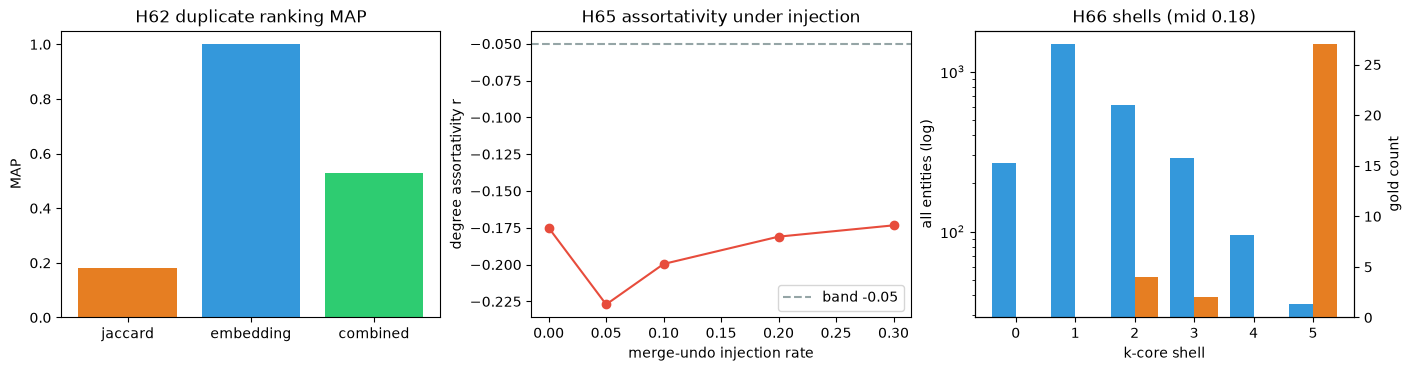

saved ../reports/structure-markers-r09-20260707-090936.json

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6), constrained_layout=True)
axes[0].bar(["jaccard", "embedding", "combined"], [map_j, map_e, map_c],
            color=["#E67E22", "#3498DB", "#2ECC71"])
axes[0].set(ylabel="MAP", title="H62 duplicate ranking MAP")
axes[1].plot(rates, r_curve, "o-", color="#E74C3C")
axes[1].axhline(BAR_H65_BAND, color="#95A5A6", ls="--", label=f"band {BAR_H65_BAND}")
axes[1].set(xlabel="merge-undo injection rate", ylabel="degree assortativity r",
            title="H65 assortativity under injection"); axes[1].legend()
allk = sorted(set(shell_dist) | set(gold_shell_dist))
w = 0.4
axes[2].bar([k - w/2 for k in allk], [shell_dist.get(k, 0) for k in allk], w,
            color="#3498DB", label="all (log)")
axes[2].set_yscale("log")
ax2b = axes[2].twinx()
ax2b.bar([k + w/2 for k in allk], [gold_shell_dist.get(k, 0) for k in allk], w,
         color="#E67E22", label="gold")
axes[2].set(xlabel="k-core shell", ylabel="all entities (log)", title=f"H66 shells (mid {mid_share:.2f})")
ax2b.set_ylabel("gold count")
plt.show()

stamp = datetime.datetime.now(datetime.timezone.utc).strftime("%Y%m%d-%H%M%S")
out = Path("../reports") / f"structure-markers-r09-{stamp}.json"
out.write_text(json.dumps({
    "h62": {"map_jaccard": map_j, "map_embedding": map_e, "map_combined": map_c,
            "n_queries": len(query_ids), "sibling_share": sib_share, "verdict": h62_verdict},
    "h64": {"top_btw_n": len(top_btw), "paths_all": paths_all, "paths_nontrivial": paths_nontrivial,
            "through_btw": through_btw, "path_share_all": path_share_all,
            "path_share_nontrivial": path_share_nt, "base_recall": base_recall,
            "btw_drop": btw_drop, "rand_drop": rand_drop,
            "damage_ratio": damage_ratio if damage_ratio != float("inf") else None,
            "verdict": h64_verdict},
    "h65": {"r_base": r_base, "rates": rates, "r_curve": r_curve, "monotonic": monotonic,
            "delta10": delta10, "verdict": h65_verdict},
    "h66": {"shell_dist": shell_dist, "gold_shell_dist": gold_shell_dist, "k_max": k_max,
            "mid_share": mid_share, "merged_kmax": merged_kmax, "verdict": h66_verdict},
}, indent=2, default=str))
rprint("saved", str(out))